# Week7-DS-Time-series prediction 

Developed in the Bioinformatics - Data science in the life science 2020, FU Berlin

Group E: ChiaAn Lee, Kunaphas Kongkitimanon, Md Nafis Rahman, Minie Jung, Wan-Ju Chang 


In [0]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline 

##### IF you use light theme ,dont run this 
plt.rcParams[
    "figure.facecolor"
] = "w"  # force white background on plots when using dark mode in JupyterLab

 ## Generate data from our model

 saved as csv files (data_B.csv, data_C.csv)

(b) from one of your SIR scenarios

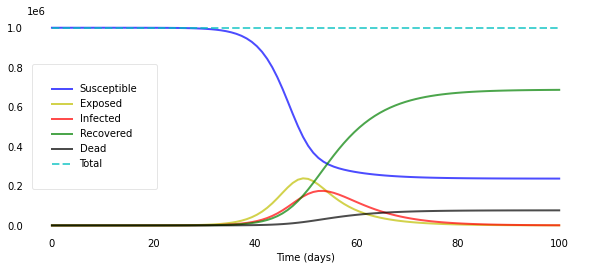

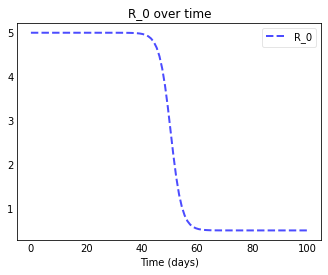

In [2]:
def logistic_R_0(t):
    return (R_0_start-R_0_end) / (1 + np.exp(-k*(-t+x0))) + R_0_end

def beta(t):
    return logistic_R_0(t) * gamma

def R_0(t):
    return 5.0 if t < L else 0.9

#def beta(t):
#    return R_0(t) * gamma

def deriv(y, t, N, beta, gamma, delta, alpha, rho):
    S, E, I, R, D = y
    dSdt = -beta(t) * S * I / N
    dEdt = beta(t) * S * I / N - delta * E
    dIdt = delta * E - (1 - alpha) * gamma * I - alpha * rho * I
    dRdt = (1 - alpha) * gamma * I
    dDdt = alpha * rho * I
    return dSdt, dEdt, dIdt, dRdt, dDdt
 
def plotseird(t, S, E, I, R, D=None, L=None, R0=None, Alpha=None, CFR=None):
  f, ax = plt.subplots(1,1,figsize=(10,4))
  ax.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
  ax.plot(t, E, 'y', alpha=0.7, linewidth=2, label='Exposed')
  ax.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected')
  ax.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
  if D is not None:
    ax.plot(t, D, 'k', alpha=0.7, linewidth=2, label='Dead')
    ax.plot(t, S+E+I+R+D, 'c--', alpha=0.7, linewidth=2, label='Total')
  else:
    ax.plot(t, S+E+I+R, 'c--', alpha=0.7, linewidth=2, label='Total')

  ax.set_xlabel('Time (days)')

  ax.yaxis.set_tick_params(length=0)
  ax.xaxis.set_tick_params(length=0)
  ax.grid(b=True, which='major', c='w', lw=2, ls='-')
  legend = ax.legend(borderpad=2.0)
  legend.get_frame().set_alpha(0.5)
  for spine in ('top', 'right', 'bottom', 'left'):
      ax.spines[spine].set_visible(False)
  if L is not None:
      plt.title("Lockdown after {} days".format(L))
  plt.show();

  if R0 is not None or CFR is not None:
    f = plt.figure(figsize=(12,4))
  
  if R0 is not None:
    # sp1
    ax1 = f.add_subplot(121)
    ax1.plot(t, R0, 'b--', alpha=0.7, linewidth=2, label='R_0')

    ax1.set_xlabel('Time (days)')
    ax1.title.set_text('R_0 over time')
    # ax.set_ylabel('Number (1000s)')
    # ax.set_ylim(0,1.2)
    ax1.yaxis.set_tick_params(length=0)
    ax1.xaxis.set_tick_params(length=0)
    ax1.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax1.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
      ax.spines[spine].set_visible(False)

  if Alpha is not None:
    # sp2
    ax2 = f.add_subplot(122)
    ax2.plot(t, Alpha, 'r--', alpha=0.7, linewidth=2, label='alpha')

    ax2.set_xlabel('Time (days)')
    ax2.title.set_text('fatality rate over time')
    # ax.set_ylabel('Number (1000s)')
    # ax.set_ylim(0,1.2)
    ax2.yaxis.set_tick_params(length=0)
    ax2.xaxis.set_tick_params(length=0)
    ax2.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax2.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
      ax.spines[spine].set_visible(False)

    plt.show();   


#L = 40 # Time-Dependent R₀ :"lockdown"
R_0_start, k, x0, R_0_end = 5.0, 0.5, 50, 0.5

N = 1_000_000
D = 4.0 # infections lasts four days
gamma = 1.0 / D
delta = 1.0 / 5.0  # incubation period of five days

alpha = 0.2  # 20% death rate
rho = 1/9  # 9 days from infection until death
S0, E0, I0, R0, D0 = N-1, 1, 0, 0, 0  # initial conditions: one exposed

t = np.linspace(0, 100, 100) # Grid of time points (in days)
y0 = S0, E0, I0, R0, D0 # Initial conditions vector

# Integrate the SIR equations over the time grid, t.
ret = odeint(deriv, y0, t, args=(N, beta, gamma, delta, alpha, rho))
S, E, I, R, D = ret.T

R0_over_time = [logistic_R_0(i) for i in range(len(t))]  # to plot R_0 over time: get function values

plotseird(t, S, E, I, R, D, R0=R0_over_time)
  

percentage going to ICU: 10.0; percentage dying in ICU: 80.0


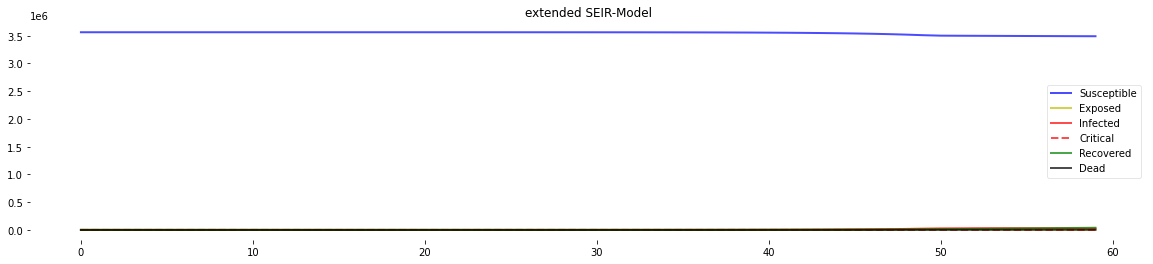

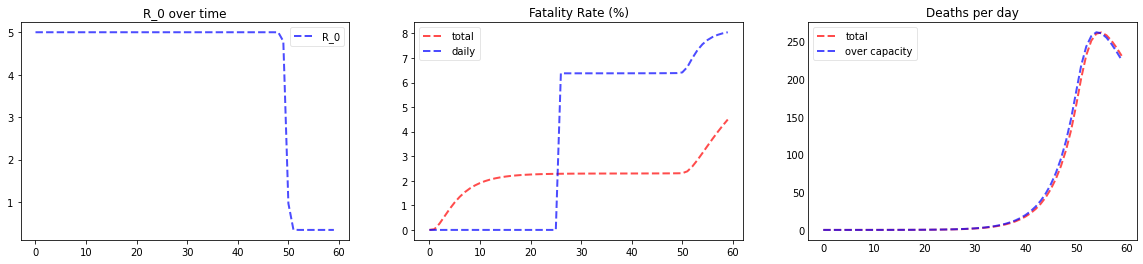

In [3]:
def plotter(t, S, E, I, C, R, D, R_0, B, S_1=None, S_2=None, x_ticks=None):
    if S_1 is not None and S_2 is not None:
      print(f"percentage going to ICU: {S_1*100}; percentage dying in ICU: {S_2 * 100}")


    f, ax = plt.subplots(1,1,figsize=(20,4))
    if x_ticks is None:
        ax.plot(t, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
        ax.plot(t, E, 'y', alpha=0.7, linewidth=2, label='Exposed')
        ax.plot(t, I, 'r', alpha=0.7, linewidth=2, label='Infected')
        ax.plot(t, C, 'r--', alpha=0.7, linewidth=2, label='Critical')
        ax.plot(t, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
        ax.plot(t, D, 'k', alpha=0.7, linewidth=2, label='Dead')
    else:
        ax.plot(x_ticks, S, 'b', alpha=0.7, linewidth=2, label='Susceptible')
        ax.plot(x_ticks, E, 'y', alpha=0.7, linewidth=2, label='Exposed')
        ax.plot(x_ticks, I, 'r', alpha=0.7, linewidth=2, label='Infected')
        ax.plot(x_ticks, C, 'r--', alpha=0.7, linewidth=2, label='Critical')
        ax.plot(x_ticks, R, 'g', alpha=0.7, linewidth=2, label='Recovered')
        ax.plot(x_ticks, D, 'k', alpha=0.7, linewidth=2, label='Dead')

        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_minor_locator(mdates.MonthLocator())
        f.autofmt_xdate()


    ax.title.set_text('extended SEIR-Model')

    ax.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
        ax.spines[spine].set_visible(False)

    plt.show();
    
    f = plt.figure(figsize=(20,4))
    # sp1
    ax1 = f.add_subplot(131)
    if x_ticks is None:
        ax1.plot(t, R_0, 'b--', alpha=0.7, linewidth=2, label='R_0')
    else:
        ax1.plot(x_ticks, R_0, 'b--', alpha=0.7, linewidth=2, label='R_0')
        ax1.xaxis.set_major_locator(mdates.YearLocator())
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax1.xaxis.set_minor_locator(mdates.MonthLocator())
        f.autofmt_xdate()

 
    ax1.title.set_text('R_0 over time')
    ax1.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax1.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
        ax.spines[spine].set_visible(False)
    
    # sp2
    ax2 = f.add_subplot(132)
    total_CFR = [0] + [100 * D[i] / sum(sigma*E[:i]) if sum(sigma*E[:i])>0 else 0 for i in range(1, len(t))]
    daily_CFR = [0] + [100 * ((D[i]-D[i-1]) / ((R[i]-R[i-1]) + (D[i]-D[i-1]))) if max((R[i]-R[i-1]), (D[i]-D[i-1]))>10 else 0 for i in range(1, len(t))]
    if x_ticks is None:
        ax2.plot(t, total_CFR, 'r--', alpha=0.7, linewidth=2, label='total')
        ax2.plot(t, daily_CFR, 'b--', alpha=0.7, linewidth=2, label='daily')
    else:
        ax2.plot(x_ticks, total_CFR, 'r--', alpha=0.7, linewidth=2, label='total')
        ax2.plot(x_ticks, daily_CFR, 'b--', alpha=0.7, linewidth=2, label='daily')
        ax2.xaxis.set_major_locator(mdates.YearLocator())
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax2.xaxis.set_minor_locator(mdates.MonthLocator())
        f.autofmt_xdate()

    ax2.title.set_text('Fatality Rate (%)')
    ax2.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax2.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
        ax.spines[spine].set_visible(False)

    # sp3
    ax3 = f.add_subplot(133)
    newDs = [0] + [D[i]-D[i-1] for i in range(1, len(t))]
    if x_ticks is None:
        ax3.plot(t, newDs, 'r--', alpha=0.7, linewidth=2, label='total')
        ax3.plot(t, [max(0, C[i]-B(i)) for i in range(len(t))], 'b--', alpha=0.7, linewidth=2, label="over capacity")
    else:
        ax3.plot(x_ticks, newDs, 'r--', alpha=0.7, linewidth=2, label='total')
        ax3.plot(x_ticks, [max(0, C[i]-B(i)) for i in range(len(t))], 'b--', alpha=0.7, linewidth=2, label="over capacity")
        ax3.xaxis.set_major_locator(mdates.YearLocator())
        ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax3.xaxis.set_minor_locator(mdates.MonthLocator())
        f.autofmt_xdate()

    ax3.title.set_text('Deaths per day')
    ax3.yaxis.set_tick_params(length=0)
    ax3.xaxis.set_tick_params(length=0)
    ax3.grid(b=True, which='major', c='w', lw=2, ls='-')
    legend = ax3.legend()
    legend.get_frame().set_alpha(0.5)
    for spine in ('top', 'right', 'bottom', 'left'):
        ax.spines[spine].set_visible(False)

    plt.show();

def deriv(y, t, beta, gamma, sigma, N, p_I_to_C, p_C_to_D, Beds):
    S, E, I, C, R, D = y

    dSdt = -beta(t) * I * S / N
    dEdt = beta(t) * I * S / N - sigma * E
    dIdt = sigma * E - i_c_rate * p_I_to_C * I - gamma * (1 - p_I_to_C) * I
    dCdt = i_c_rate * p_I_to_C * I - c_d_rate * p_C_to_D * min(Beds(t), C) - max(0, C-Beds(t)) - (1 - p_C_to_D) * c_r_rate * min(Beds(t), C)
    dRdt = gamma * (1 - p_I_to_C) * I + (1 - p_C_to_D) *c_r_rate * min(Beds(t), C)
    dDdt = c_d_rate * p_C_to_D * min(Beds(t), C) + max(0, C-Beds(t))
    return dSdt, dEdt, dIdt, dCdt, dRdt, dDdt


def logistic_R_0(t, R_0_start, k, x0, R_0_end):
    return (R_0_start-R_0_end) / (1 + np.exp(-k*(-t+x0))) + R_0_end


def beta(t):
    return logistic_R_0(t, R_0_start, k, x0, R_0_end) * gamma

def Beds(t):
    beds_0 = beds /  N
    return beds_0 + s*beds_0*t  # 0.003

#-----------------------------------------------------------------------------------------------------------
# N: total population
N = 3_562_000 # From https://www.macrotrends.net/cities/204296/berlin/population

# S(t): number of people susceptible on day t

# E(t): number of people exposed on day t

# I(t): number of people infected on day t

# R(t): number of people recovered on day t

# D(t): number of people dead on day t

# β(t): expected amount of people an infected person infects per day

# γ: the proportion of infected recovering per day (γ = 1/D) -> gamma 
gamma = 1.0/9.0 # <--- D = 9.0 infections lasts four days
# R₀_start (parameter in R₀(t))
R_0_start =4.999999999999999
# R₀_end (parameter in R₀(t))
R_0_end = 0.3452968277080277
# x₀ (parameter in R₀(t)) is the x-value of the inflection point (i.e. the date of the steepest decline in R_0, this could be thought of as the main “lockdown” date
x0 = 49.62
# k (parameter in R₀(t))  lets us vary how quickly R_0 declines
k = 4.9
# s (parameter in Beds(t))
s = 0.0010000000000000002
# Beds₀ (parameter in R₀(t))

# δ: length of incubation period -> sigma 
sigma = 1.0/3.0
# p(I→C): probability of going from infected to critical
prob_I_to_C = 0.09999999999999999
# p(C→D): probability of dying while critical
prob_C_to_D = 0.7999999999999999

beds = 2267

# Number of days from infected to critical
i_c_rate = 1/12.0
# Number of days from critical to dead
c_d_rate = 1/7.5
# Number of days from critical to recovered
c_r_rate = 1/6.5

#
days = 60
#-----------------------------------------------------------------------------------------------------------


y0 = N-1.0, 1.0, 0.0, 0.0, 0.0, 0.0
t = np.linspace(0, days-1, days)
ret = odeint(deriv, y0, t, args=(beta, gamma, sigma, N, prob_I_to_C, prob_C_to_D, Beds))
S, E, I, C, R, D = ret.T
R_0_over_time = [beta(i)/gamma for i in range(len(t))]

plotter(t, S, E, I, C, R, D, R_0_over_time, Beds, prob_I_to_C, prob_C_to_D)

In [0]:
I= I.astype(int)
t= t.astype(int)

data = {'Time': t,
        'Infected  Cases': I}

df_B = pd.DataFrame (data, columns = ['Time','Infected  Cases'])
df_B.to_csv('data_B.csv')

(c) from one of your agent-based scenarios

In [5]:
!pip3 install  git+https://github.com/mj0410/DS_week6_ABM

  Cloning https://github.com/mj0410/DS_week6_ABM to /tmp/pip-req-build-ikizjq6k
  Running command git clone -q https://github.com/mj0410/DS_week6_ABM /tmp/pip-req-build-ikizjq6k
  Created wheel for covid-abs: filename=covid_abs-0.0.2-cp36-none-any.whl size=31272 sha256=652dc59387b0cf0e42e71d9c9117245d4b50e9ae1e86b64e0ba84660d1a9b3ae
  Stored in directory: /tmp/pip-ephem-wheel-cache-x5aa1fc2/wheels/fe/f3/a2/78cfaa02a26303eee48c4e7616427975c99f8f08d721069bd6
Successfully built covid-abs


In [6]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import animation, rc
from IPython.display import HTML

warnings.simplefilter('ignore')
from covid_abs.experiments import batch_experiment
from covid_abs.abs import *
from covid_abs.graphics import *

batch_experiment(20, 100, "data_C.csv",
                  # Percentage of infected in initial population
                  initial_infected_perc=0.02,
                  # Percentage of immune in initial population
                  initial_immune_perc=0.01,
                  # Length of simulation environment
                  length=200,
                  # Height of simulation environment
                  height=200,
                  # Size of population
                  population_size=200,
                  # Minimal distance between agents for contagion
                  contagion_distance=5.,
                  # Maximum percentage of population which Healthcare System can handle simutaneously
                  critical_limit=0.05,
                  # Mobility ranges for agents, by Status
                 
                  # Percentage of exposed in initial population <---- New Update 
                  initial_exposed_perc = 0,
                  # incubation period <---- New Update 
                  incubation_period = 14,                 

                  amplitudes={
                      Status.Susceptible: 8,
                      Status.Recovered_Immune: 8,
                      Status.Infected: 8,
                      Status.Exposed : 8 
                  },
                 triggers_simulation=[
                     {'condition': lambda a: a.get_iteration()> 17, # 17 Mar ,lockdown
                      'attribute': 'amplitudes',
                      'action': lambda a: {
                          Status.Susceptible : 2, 
                          Status.Recovered_Immune : 2, 
                          Status.Infected : 2 ,
                          Status.Exposed : 2 
                      }},
                     {'condition': lambda a: a.get_iteration()> 17, # 24 Apr, open store
                      'attribute': 'amplitudes',
                      'action': lambda a: {
                          Status.Susceptible : 5, 
                          Status.Recovered_Immune : 5, 
                          Status.Infected : 5 ,
                          Status.Exposed : 5
                      }}
                 ])

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


[[0, 'Susceptible', 0.94, 0.959, 0.01102270384252431, 0.97], [0, 'Infected', 0.02, 0.029750000000000006, 0.01018270592720815, 0.05], [0, 'Recovered_Immune', 0.01, 0.010000000000000002, 1.734723475976807e-18, 0.01], [0, 'Death', 0.0, 0.00025, 0.0010897247358851686, 0.005], [0, 'Exposed', 0.0, 0.001, 0.002, 0.005], [0, 'Asymptomatic', 0.995, 0.9995, 0.0015000000000000013, 1.0], [0, 'Hospitalization', 0.0, 0.00025, 0.0010897247358851686, 0.005], [0, 'Severe', 0.0, 0.0, 0.0, 0.0], [0, 'Q1', 467.2460025702269, 507.46401565281167, 30.15807397218237, 569.8575905673463], [0, 'Q2', 910.9381506229407, 991.9114880891169, 54.382986645634254, 1091.6429640298393], [0, 'Q3', 1374.0622305241027, 1614.1894349791812, 95.39884341458563, 1766.9600504502173], [0, 'Q4', 2308.4919935717894, 2540.7269446027103, 152.4590384439786, 2946.2096440409214], [0, 'Q5', 6525.084065363938, 6974.4333874843605, 317.18536936709825, 7597.851650298157], [1, 'Susceptible', 0.92, 0.9487500000000001, 0.01780975856096873, 0.97],

,Iteration,Metric,Min,Avg,Std,Max
0,0,Susceptible,0.940000,0.959000,1.102270e-02,0.970000
1,0,Infected,0.020000,0.029750,1.018271e-02,0.050000
2,0,Recovered_Immune,0.010000,0.010000,1.734723e-18,0.010000
3,0,Death,0.000000,0.000250,1.089725e-03,0.005000
4,0,Exposed,0.000000,0.001000,2.000000e-03,0.005000
...,...,...,...,...,...,...
1295,99,Q1,4148.340204,6279.556526,9.007576e+02,7908.356163
1296,99,Q2,8340.207337,11367.239570,1.677618e+03,14241.768168
1297,99,Q3,15214.019371,19257.286157,2.996413e+03,27731.898079
1298,99,Q4,20067.185148,29801.920640,4.070306e+03,38546.800243
